In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

In [18]:
df_customers = pd.read_csv(r"E:\DS\tezendra\Projects\Marketing Analysis\Customer Behavior & Sales 2020–2026\customers.csv")
df_orders = pd.read_csv(r"E:\DS\tezendra\Projects\Marketing Analysis\Customer Behavior & Sales 2020–2026\orders.csv")


In [19]:
df_customers.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


In [20]:
np.sort(df_customers["preferred_category"].unique())


array(['Automotive', 'Beauty & Personal Care', 'Books',
       'Clothing & Apparel', 'Electronics', 'Food & Grocery',
       'Health & Wellness', 'Home & Kitchen', 'Jewelry & Accessories',
       'Office Supplies', 'Pet Supplies', 'Sports & Outdoors',
       'Toys & Games', 'Travel & Luggage'], dtype=object)

In [21]:
np.sort(df_orders["category"].unique())

array(['Automotive', 'Beauty & Personal Care', 'Books',
       'Clothing & Apparel', 'Electronics', 'Food & Grocery',
       'Health & Wellness', 'Home & Kitchen', 'Jewelry & Accessories',
       'Office Supplies', 'Pet Supplies', 'Sports & Outdoors',
       'Toys & Games', 'Travel & Luggage'], dtype=object)

In [22]:
df_customers["preferred_payment_method"].unique()

array(['Debit Card', 'PayPal', 'UPI / Digital Wallet', 'Credit Card',
       'Bank Transfer', 'Cryptocurrency', 'Buy Now Pay Later'],
      dtype=object)

In [23]:
df_orders.head()

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1


In [24]:
df_customers.describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


In [25]:
df_orders.describe()

,year,month,unit_price_usd,quantity,subtotal_usd,discount_pct,discount_amount_usd,shipping_fee_usd,tax_pct,tax_amount_usd,total_amount_usd,delivery_days,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,9251.000000,25000.000000,25000.00000,25000.000000
mean,2022.652840,6.352280,68.124030,1.695520,116.187322,5.630000,6.345500,3.867579,10.677080,11.746785,125.456186,4.179480,0.080800,4.002324,16.780432,6.51256,0.645960
std,1.814996,3.514614,57.258933,1.045436,136.994998,9.740785,17.530764,3.269618,6.504922,17.723056,145.635016,2.548507,0.272533,0.577576,15.811830,5.26557,0.478231
min,2020.000000,1.000000,3.360000,1.000000,3.360000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,1.500000,0.300000,1.00000,0.000000
25%,2021.000000,3.000000,29.250000,1.000000,38.467500,0.000000,0.000000,0.000000,8.000000,2.300000,43.450000,3.000000,0.000000,3.600000,7.100000,2.00000,0.000000
50%,2023.000000,6.000000,51.530000,1.000000,72.390000,0.000000,0.000000,3.990000,10.000000,6.220000,78.775000,4.000000,0.000000,4.100000,12.100000,5.00000,1.000000
75%,2024.000000,9.000000,87.877500,2.000000,140.160000,10.000000,5.250000,6.990000,18.000000,13.990000,149.872500,5.000000,0.000000,4.400000,21.100000,9.00000,1.000000
max,2026.000000,12.000000,697.030000,5.000000,2636.450000,50.000000,421.580000,9.990000,20.000000,303.990000,2730.880000,14.000000,1.000000,5.000000,361.200000,24.00000,1.000000


In [26]:
df_customers.isnull().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

In [27]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_date                          0
year                                0
month                               0
quarter                             0
day_of_week                         0
product_name                        0
category                            0
unit_price_usd                      0
quantity                            0
subtotal_usd                        0
discount_pct                        0
discount_amount_usd                 0
shipping_fee_usd                    0
tax_pct                             0
tax_amount_usd                      0
total_amount_usd                    0
payment_method                      0
device_used                         0
delivery_days                       0
delivery_date                       0
order_status                        0
returned                            0
customer_rating                 15749
session_duration_minutes            0
pages_viewed

In [28]:
df_orders['customer_rating'].describe()

count    9251.000000
mean        4.002324
std         0.577576
min         1.500000
25%         3.600000
50%         4.100000
75%         4.400000
max         5.000000
Name: customer_rating, dtype: float64

In [29]:
imputer = KNNImputer(n_neighbors=5)
df_orders['customer_rating'] = imputer.fit_transform(df_orders[['customer_rating']])


In [30]:
df_orders['customer_rating'].describe() 

count    25000.000000
mean         4.002324
std          0.351333
min          1.500000
25%          4.002324
50%          4.002324
75%          4.002324
max          5.000000
Name: customer_rating, dtype: float64

In [31]:
join_df = pd.merge(
    df_orders,
    df_customers,
    how="outer",
    on="customer_id",
    suffixes=("_order", "_customer")
)
join_df.head()

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,O005822,C00001,2025-09-05,2025.0,9.0,Q3,Friday,Cycling Gloves,Sports & Outdoors,73.38,...,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,O019988,C00001,2021-10-05,2021.0,10.0,Q4,Tuesday,Smart Plug 4-Pack,Electronics,93.63,...,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
2,O004925,C00002,2025-12-24,2025.0,12.0,Q4,Wednesday,Puzzle 1000pc,Toys & Games,25.89,...,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
3,O005852,C00002,2023-07-18,2023.0,7.0,Q3,Tuesday,LEGO City Set,Toys & Games,32.62,...,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
4,O009040,C00002,2026-03-30,2026.0,3.0,Q1,Monday,Smart Plug 4-Pack,Electronics,346.46,...,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0


In [32]:
plt.figure(figsize=(10, 6))
for name, df in {
    "Customers": df_customers,
    "Orders": df_orders,
    "Joined": join_df
}.items():
    df.select_dtypes("number").hist(figsize=(12, 8), bins=20)
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\thapa\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\LastResortHE-Regular.ttf'

Error in callback <function _draw_all_if_interactive at 0x0000020E29E31260> (for post_execute), with arguments args (),kwargs {}:


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\thapa\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\LastResortHE-Regular.ttf'

<Figure size 1000x600 with 0 Axes>

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\thapa\\anaconda3\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\LastResortHE-Regular.ttf'

<Figure size 1200x800 with 12 Axes>

Churn classifier: XGBoost/LightGBM from days_since_last_purchase, total_orders, RFM

<Axes: ylabel='Frequency'>

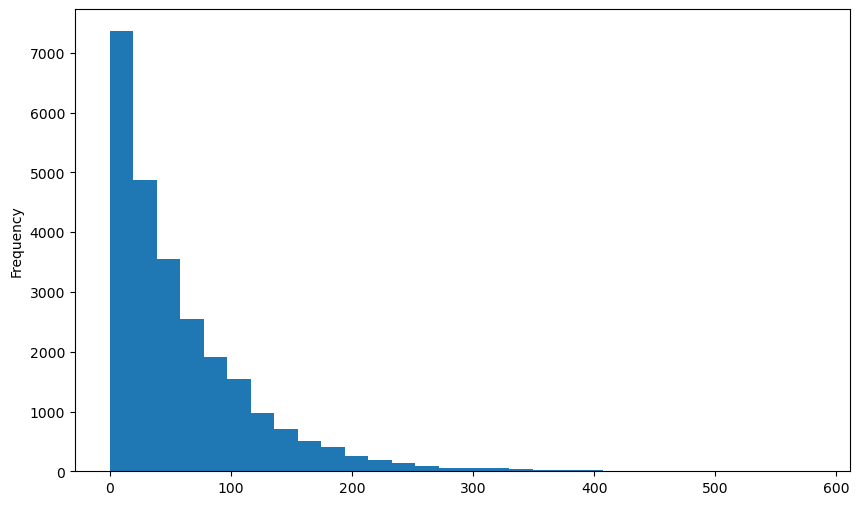

In [ ]:
join_df['days_since_last_purchase'].plot(kind='hist', bins=30, figsize=(10, 6))

In [ ]:
LQ = join_df['days_since_last_purchase'].quantile(0.25)
HQ = join_df['days_since_last_purchase'].quantile(0.75)

IQR = HQ - LQ

join_df = join_df[
    join_df['days_since_last_purchase'].between(
        LQ - 1.5 * IQR,
        HQ + 1.5 * IQR
    )
]

<Axes: title={'center': 'Days Since Last Purchase Distribution'}, ylabel='Frequency'>

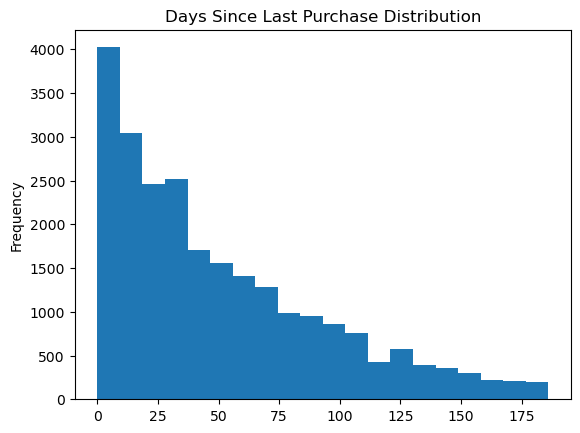

In [ ]:
join_df['days_since_last_purchase'].plot(kind='hist', bins=20, title='Days Since Last Purchase Distribution')

1. Churn Prediction Model
Identifies high-risk churn customers using behavioral and RFM metrics.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

rfm_behavioral_features = [
    "total_orders",
    "total_spend_usd",
    "avg_order_value_usd",
    "days_since_last_purchase",
    "reviews_given",
    "avg_review_score",
    "returns_made",
    "wishlist_items",
    "newsletter_subscribed",
]

X = df_customers[rfm_behavioral_features]
y = df_customers["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("--- Churn Model Evaluation ---")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred))

--- Churn Model Evaluation ---
ROC-AUC Score: 0.7442
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1457
           1       0.45      0.13      0.21       143

    accuracy                           0.91      1600
   macro avg       0.69      0.56      0.58      1600
weighted avg       0.88      0.91      0.88      1600



2. Customer RFM Segmentation
Clusters users into behavioral cohorts to tailor promotional targeting.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

rfm_features = ["days_since_last_purchase", "total_orders", "total_spend_usd"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_customers[rfm_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_customers["cluster"] = kmeans.fit_predict(rfm_scaled)

print("--- Segment Profile Means ---")
print(
    df_customers.groupby("cluster")[rfm_features]
    .mean()
    .rename(
        columns={
            "days_since_last_purchase": "Recency (Days)",
            "total_orders": "Frequency (Orders)",
            "total_spend_usd": "Monetary ($)",
        }
    )
)

--- Segment Profile Means ---
         Recency (Days)  Frequency (Orders)  Monetary ($)
cluster                                                  
0             45.137356           35.698851   3063.236787
1            164.788984           12.696664   1046.816749
2             60.973684           47.721053  11612.378105
3             36.422087            9.373144    749.510178


3. Monthly GMV Time Series Forecasting
Forecasts total monthly revenue using a Seasonal Autoregressive Integrated Moving Average (SARIMAX) model.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
monthly_gmv = (
    df_orders.resample("ME", on="order_date")["total_amount_usd"]
    .sum()
    .to_frame()
)

model = SARIMAX(
    monthly_gmv,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit(disp=False)

forecast = results.get_forecast(steps=12)
forecast_df = forecast.conf_int()
forecast_df["forecast"] = forecast.predicted_mean

print("--- 12-Month GMV Forecast ---")
print(forecast_df[["forecast", "lower total_amount_usd", "upper total_amount_usd"]].head())

--- 12-Month GMV Forecast ---
                forecast  lower total_amount_usd  upper total_amount_usd
2026-04-30  44148.020506            34401.669327            53894.371685
2026-05-31  46864.302865            37062.060991            56666.544739
2026-06-30  48695.069134            38797.923476            58592.214792
2026-07-31  47724.511999            37734.984383            57714.039615
2026-08-31  45774.289423            35693.134170            55855.444675


4. Cross-Selling Market Basket Analysis
Discovers product category relationships using the Apriori algorithm.

In [ ]:
%pip install -q mlxtend

from mlxtend.frequent_patterns import apriori, association_rules

basket = (
    df_orders.groupby(["order_id", "category"])["quantity"]
    .sum()
    .unstack()
    .fillna(0)
)
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

frequent_itemsets = apriori(
    basket_sets, min_support=0.01, use_colnames=True
)
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=1.0
)

print("--- Market Basket Rules ---")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head())

Note: you may need to restart the kernel to use updated packages.
--- Market Basket Rules ---
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


C:\Users\thapa\AppData\Local\Temp\ipykernel_36380\3114403925.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)
c:\Users\thapa\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


5. Product Return Risk Diagnostics
Evaluates order-level operational and behavioral attributes that drive product returns using Logistic Regression.

In [33]:
import statsmodels.api as sm

order_features = [
    "unit_price_usd",
    "quantity",
    "discount_pct",
    "delivery_days",
    "session_duration_minutes",
    "pages_viewed_before_purchase",
]

X_returns = df_orders[order_features]
X_returns = sm.add_constant(X_returns)
y_returns = df_orders["returned"]

logit_model = sm.Logit(y_returns, X_returns).fit(disp=False)

print("--- Product Return Drivers (Logistic Regression) ---")
print(logit_model.summary().tables[1])

--- Product Return Drivers (Logistic Regression) ---
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.4252      0.076    -31.960      0.000      -2.574      -2.276
unit_price_usd                   0.0003      0.000      0.689      0.491      -0.001       0.001
quantity                        -0.0210      0.023     -0.933      0.351      -0.065       0.023
discount_pct                    -0.0007      0.002     -0.282      0.778      -0.005       0.004
delivery_days                   -0.0036      0.009     -0.394      0.693      -0.022       0.014
session_duration_minutes         0.0007      0.001      0.520      0.603      -0.002       0.004
pages_viewed_before_purchase     0.0025      0.004      0.577      0.564      -0.006       0.011
